In [ ]:
!pip install torch torchvision pandas numpy matplotlib seaborn scikit-learn tqdm --quiet

In [ ]:
import os
import zipfile
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import os
import zipfile
import pandas as pd

zip_name = list(uploaded.keys())[0]
extract_path = "/content/data"

with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall(extract_path)

all_files = []

for root, dirs, files_in_dir in os.walk(extract_path):
    for file in files_in_dir:
        all_files.append(os.path.join(root, file))

print("All extracted files:")
for f in all_files:
    print(f)

csv_files = [f for f in all_files if f.lower().endswith(".csv")]

if len(csv_files) == 0:
    raise Exception("No CSV file found. You probably uploaded the wrong dataset ZIP.")

csv_path = csv_files[0]
print("CSV path:", csv_path)

df = pd.read_csv(csv_path)

print("Dataset loaded successfully")
print("Shape:", df.shape)
display(df.head())

All extracted files:
/content/data/fer2013.csv
CSV path: /content/data/fer2013.csv
Dataset loaded successfully
Shape: (35887, 3)


,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [ ]:
def process_pixels(pixels):
    image = np.array(pixels.split(), dtype=np.float32)
    image = image.reshape(48, 48)
    return image

df["image"] = df["pixels"].apply(process_pixels)

X = np.stack(df["image"].values)
X = X / 255.0
X = np.expand_dims(X, axis=1)

y = df["emotion"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (35887, 1, 48, 48)
y shape: (35887,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.15,
    random_state=42,
    stratify=y_train_full
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (24402, 1, 48, 48) (24402,)
Validation: (4307, 1, 48, 48) (4307,)
Test: (7178, 1, 48, 48) (7178,)


In [ ]:
from torch.utils.data import Dataset

class FERDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx][0]
        img = (img * 255).astype(np.uint8)

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(self.y[idx], dtype=torch.long)

        return img, label

In [ ]:
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

def get_loaders(batch_size=32, use_aug=False, use_weighted_sampler=True):
    train_tf = aug if use_aug else no_aug

    train_ds = FERDataset(X_train, y_train, transform=train_tf)
    val_ds   = FERDataset(X_val, y_val, transform=no_aug)
    test_ds  = FERDataset(X_test, y_test, transform=no_aug)

    if use_weighted_sampler:
        # inverse-frequency weighting per class
        class_counts = np.bincount(y_train)
        class_weights = 1.0 / class_counts
        sample_weights = class_weights[y_train]

        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(y_train),
            replacement=True
        )
        train_loader = DataLoader(
            train_ds,
            batch_size=batch_size,
            sampler=sampler  # NOTE: don't pass shuffle when using a sampler
        )
        print(f"Using WeightedRandomSampler. Class counts: {class_counts.tolist()}")
    else:
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    val_loader  = DataLoader(val_ds,  batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [ ]:
from torchvision import transforms

no_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [ ]:
from torchvision import models
import torch.nn as nn

def build_efficientnet(dropout_rate=0.3):
    model = models.efficientnet_b0(
        weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
    )

    for param in model.parameters():
        param.requires_grad = False


    for param in model.features[6:].parameters():
        param.requires_grad = True


    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(dropout_rate),
        nn.Linear(in_features, 7)
    )

    return model.to(device)

In [ ]:
import copy
from tqdm import tqdm
import torch.optim as optim

def train_model(model, train_loader, val_loader, lr=0.0001, epochs=10, patience=5):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=1e-4
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0
    early_stop_counter = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        print("-" * 30)

        model.train()
        train_loss = 0
        train_correct = 0

        for images, labels in tqdm(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            preds = torch.argmax(outputs, dim=1)

            train_loss += loss.item() * images.size(0)
            train_correct += (preds == labels).sum().item()

        train_loss = train_loss / len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)

        model.eval()
        val_loss = 0
        val_correct = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader):
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                preds = torch.argmax(outputs, dim=1)

                val_loss += loss.item() * images.size(0)
                val_correct += (preds == labels).sum().item()

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            early_stop_counter = 0
            print("Best model updated")
        else:
            early_stop_counter += 1
            print("No improvement")

        if early_stop_counter >= patience:
            print("Early stopping triggered")
            break

    model.load_state_dict(best_model_wts)
    return model, history, best_val_acc

In [ ]:


   FERDataset
no_aug
aug
X_train, X_val, X_test
y_train, y_val, y_test

(array([2, 3, 3, ..., 3, 3, 6]),
 array([4, 4, 2, ..., 0, 6, 0]),
 array([3, 2, 3, ..., 6, 2, 5]))

In [ ]:
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

def get_loaders(batch_size=32, use_aug=False, use_weighted_sampler=True):
    train_tf = aug if use_aug else no_aug

    train_ds = FERDataset(X_train, y_train, transform=train_tf)
    val_ds   = FERDataset(X_val, y_val, transform=no_aug)
    test_ds  = FERDataset(X_test, y_test, transform=no_aug)

    if use_weighted_sampler:
        # inverse-frequency weighting per class
        class_counts = np.bincount(y_train)
        class_weights = 1.0 / class_counts
        sample_weights = class_weights[y_train]

        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(y_train),
            replacement=True
        )
        train_loader = DataLoader(
            train_ds,
            batch_size=batch_size,
            sampler=sampler  # NOTE: don't pass shuffle when using a sampler
        )
        print(f"Using WeightedRandomSampler. Class counts: {class_counts.tolist()}")
    else:
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    val_loader  = DataLoader(val_ds,  batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [ ]:
train_loader, val_loader, test_loader = get_loaders(batch_size=32, use_aug=False)

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [ ]:
print("Number of experiments:", len(experiments))
print(experiments[0]["name"])

print("Checking functions...")
print(get_loaders)
print(build_efficientnet)
print(train_model)

Number of experiments: 4
No Augmentation | LR=0.0001 | Batch=32 | Dropout=0.3
Checking functions...
<function get_loaders at 0x7f9c501013a0>
<function build_efficientnet at 0x7f9c50100720>
<function train_model at 0x7f9c50100a40>


In [ ]:
exp = experiments[0]

print("Starting mini test:", exp["name"])

train_loader, val_loader, test_loader = get_loaders(
    batch_size=exp["batch_size"],
    use_aug=exp["augmentation"]
)

print("Loaders ready")

model = build_efficientnet(dropout_rate=exp["dropout"])
print("Model ready")

model, history, best_val_acc = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    lr=exp["lr"],
    epochs=1,
    patience=1
)

print("Mini test finished")
print("Best val acc:", best_val_acc)

Starting mini test: No Augmentation | LR=0.0001 | Batch=32 | Dropout=0.3
Loaders ready
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 142MB/s]


Model ready

Epoch 1/1
------------------------------


100%|██████████| 135/135 [00:11<00:00, 12.02it/s]

Train Loss: 1.3473 | Train Acc: 0.4891
Val Loss:   1.1142 | Val Acc:   0.5811
Best model updated
Mini test finished
Best val acc: 0.5811469700487578


In [ ]:
experiments = [
    {
        "name": "No Augmentation | LR=0.0001 | Batch=32 | Dropout=0.3",
        "augmentation": False,
        "lr": 0.0001,
        "batch_size": 32,
        "dropout": 0.3,
        "epochs": 25
    },
    {
        "name": "With Augmentation | LR=0.0001 | Batch=32 | Dropout=0.3",
        "augmentation": True,
        "lr": 0.0001,
        "batch_size": 32,
        "dropout": 0.3,
        "epochs": 25
    },
    {
        "name": "With Augmentation | LR=0.0003 | Batch=32 | Dropout=0.3",
        "augmentation": True,
        "lr": 0.0003,
        "batch_size": 32,
        "dropout": 0.3,
        "epochs": 25
    },
    {
        "name": "With Augmentation | LR=0.0001 | Batch=64 | Dropout=0.5",
        "augmentation": True,
        "lr": 0.0001,
        "batch_size": 64,
        "dropout": 0.5,
        "epochs": 25
    }
]

In [ ]:
print("Starting experiments...")

results = []

for exp in experiments:
    print("\n" + "=" * 80)
    print("Running:", exp["name"])
    print("=" * 80)

    train_loader, val_loader, test_loader = get_loaders(
        batch_size=exp["batch_size"],
        use_aug=exp["augmentation"]
    )

    model = build_efficientnet(dropout_rate=exp["dropout"])

    model, history, best_val_acc = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        lr=exp["lr"],
        epochs=exp["epochs"],
        patience=3
    )

    results.append({
        "name": exp["name"],
        "model": model,
        "history": history,
        "best_val_acc": best_val_acc,
        "test_loader": test_loader,
        "settings": exp
    })

    print("Finished:", exp["name"])
    print("Best Val Acc:", best_val_acc)

print("All experiments finished")

Starting experiments...

Running: No Augmentation | LR=0.0001 | Batch=32 | Dropout=0.3
Using WeightedRandomSampler. Class counts: [3368, 372, 3482, 6112, 4132, 2722, 4214]

Epoch 1/25
------------------------------


100%|██████████| 135/135 [00:11<00:00, 11.84it/s]


Train Loss: 1.4553 | Train Acc: 0.5016
Val Loss:   1.3523 | Val Acc:   0.5514
Best model updated

Epoch 2/25
------------------------------


100%|██████████| 135/135 [00:11<00:00, 11.53it/s]


Train Loss: 1.1502 | Train Acc: 0.6646
Val Loss:   1.3042 | Val Acc:   0.5863
Best model updated

Epoch 3/25
------------------------------


...

100%|██████████| 135/135 [00:11<00:00, 11.81it/s]


Train Loss: 1.2380 | Train Acc: 0.6141
Val Loss:   1.2734 | Val Acc:   0.5951
Best model updated

Epoch 3/25
------------------------------


100%|██████████| 135/135 [00:11<00:00, 11.73it/s]


Train Loss: 1.1583 | Train Acc: 0.6537
Val Loss:   1.2472 | Val Acc:   0.6127
Best model updated

Epoch 4/25
------------------------------


 66%|██████▌   | 500/763 [01:25<00:48,  5.42it/s]

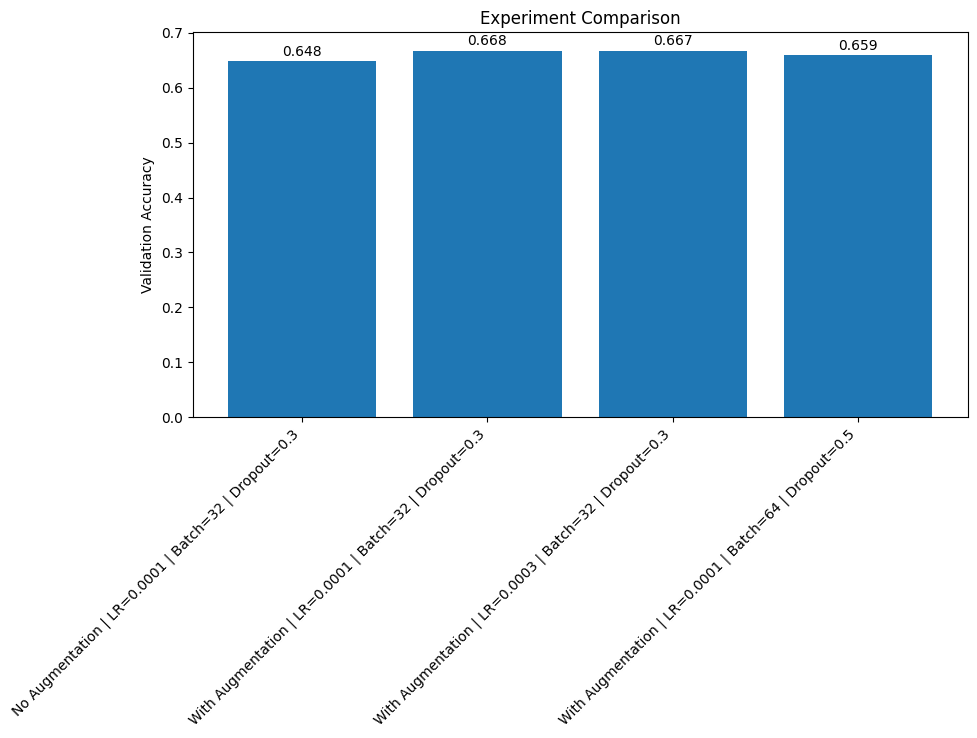

In [ ]:
import matplotlib.pyplot as plt

names = [r["name"] for r in results]
accs  = [r["best_val_acc"] for r in results]

plt.figure(figsize=(10,5))
plt.bar(names, accs)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Validation Accuracy")
plt.title("Experiment Comparison")

for i, v in enumerate(accs):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.show()

In [ ]:
import numpy as np

best_idx = np.argmax(accs)
best_model = results[best_idx]["model"]
best_loader = results[best_idx]["test_loader"]

print("Best experiment:")
print(results[best_idx]["name"])
print("Best Val Accuracy:", results[best_idx]["best_val_acc"])

Best experiment:
With Augmentation | LR=0.0001 | Batch=32 | Dropout=0.3
Best Val Accuracy: 0.6677501741351288


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_true = []
y_pred = []

best_model.eval()

with torch.no_grad():
    for images, labels in best_loader:
        images = images.to(device)

        outputs = best_model(images)
        preds = torch.argmax(outputs, dim=1).cpu()

        y_pred.extend(preds.numpy())
        y_true.extend(labels.numpy())

print("Test Accuracy:", accuracy_score(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Test Accuracy: 0.6792978545555866

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.55      0.60       991
           1       0.77      0.50      0.60       109
           2       0.52      0.56      0.54      1024
           3       0.86      0.88      0.87      1798
           4       0.58      0.55      0.57      1216
           5       0.78      0.78      0.78       800
           6       0.59      0.66      0.63      1240

    accuracy                           0.68      7178
   macro avg       0.68      0.64      0.66      7178
weighted avg       0.68      0.68      0.68      7178



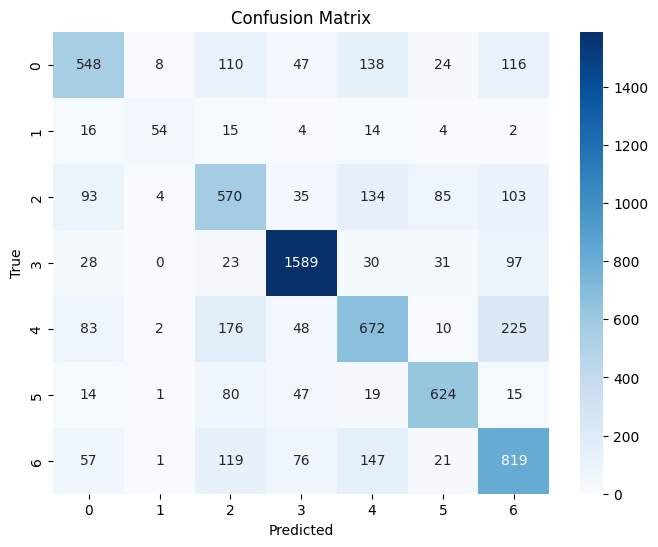

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

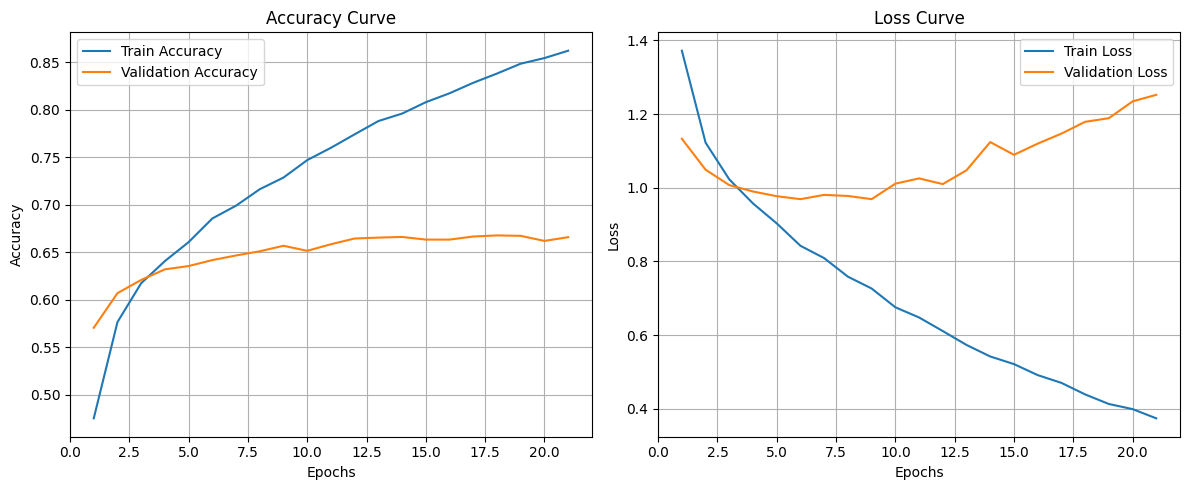

In [ ]:
best_history = results[best_idx]["history"]

epochs = range(1, len(best_history["train_acc"]) + 1)

plt.figure(figsize=(12,5))

# 🔹 Accuracy plot
plt.subplot(1,2,1)
plt.plot(epochs, best_history["train_acc"], label="Train Accuracy")
plt.plot(epochs, best_history["val_acc"], label="Validation Accuracy")

plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# 🔹 Loss plot
plt.subplot(1,2,2)
plt.plot(epochs, best_history["train_loss"], label="Train Loss")
plt.plot(epochs, best_history["val_loss"], label="Validation Loss")

plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from torchvision import transforms

aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.08, 0.08),
        scale=(0.95, 1.05)
    ),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

print("Stronger augmentation updated")

Stronger augmentation updated


In [ ]:
experiments = [
    {
        "name": "Final + Sampler + AdamW + LabelSmooth",
        "augmentation": True,
        "lr": 0.00005,
        "batch_size": 32,
        "dropout": 0.5,
        "epochs": 30
    }
]

print("Final tuned experiment ready")

In [ ]:
results = []

for exp in experiments:
    print("Running:", exp["name"])

    train_loader, val_loader, test_loader = get_loaders(
        batch_size=exp["batch_size"],
        use_aug=exp["augmentation"]
    )

    model = build_efficientnet(dropout_rate=exp["dropout"])

    model, history, best_val_acc = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        lr=exp["lr"],
        epochs=exp["epochs"],
        patience=3
    )

    results.append({
        "name": exp["name"],
        "model": model,
        "history": history,
        "best_val_acc": best_val_acc,
        "test_loader": test_loader,
        "settings": exp
    })

print("Final tuned experiment finished")

Running: Final Tuned EfficientNet-B0 | Augmentation | LR=0.00005 | Batch=32 | Dropout=0.5

Epoch 1/25
------------------------------


100%|██████████| 135/135 [00:11<00:00, 11.69it/s]


Train Loss: 1.5637 | Train Acc: 0.3937
Val Loss:   1.3201 | Val Acc:   0.5024
Best model updated

Epoch 2/25
------------------------------


100%|██████████| 135/135 [00:11<00:00, 11.82it/s]


Train Loss: 1.2810 | Train Acc: 0.5128
Val Loss:   1.1773 | Val Acc:   0.5498
Best model updated

Epoch 3/25
------------------------------


...

Train Loss: 0.7241 | Train Acc: 0.7288
Val Loss:   0.9770 | Val Acc:   0.6566
No improvement

Epoch 24/25
------------------------------


100%|██████████| 135/135 [00:11<00:00, 11.72it/s]


Train Loss: 0.7053 | Train Acc: 0.7354
Val Loss:   0.9777 | Val Acc:   0.6631
No improvement

Epoch 25/25
------------------------------


100%|██████████| 135/135 [00:13<00:00, 10.15it/s]

Train Loss: 0.6943 | Train Acc: 0.7411
Val Loss:   0.9900 | Val Acc:   0.6606
No improvement
Early stopping triggered
Final tuned experiment finished


In [ ]:
best_idx = 0
best_history = results[best_idx]["history"]

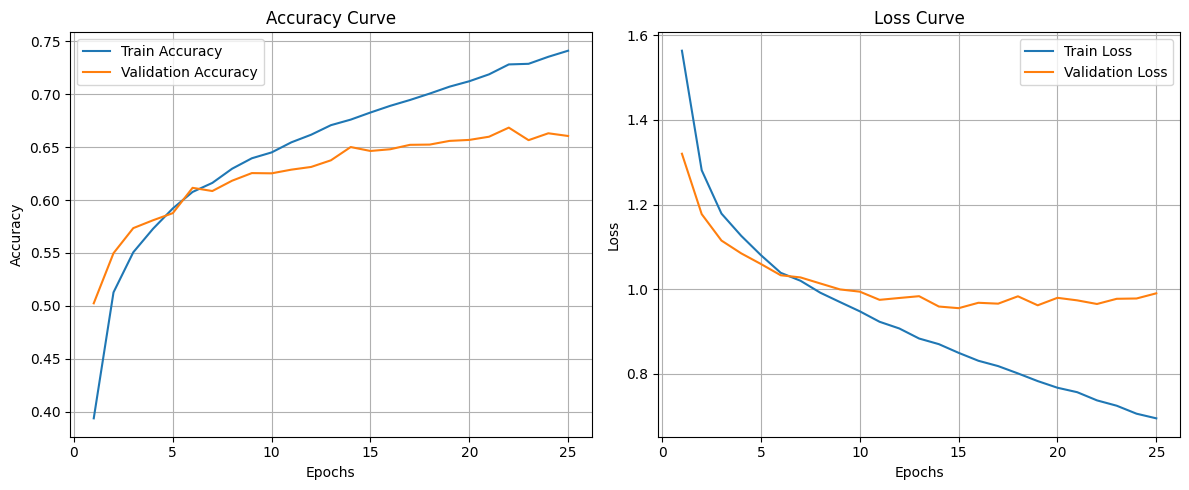

In [ ]:
import matplotlib.pyplot as plt

# since you only have 1 experiment now
best_idx = 0
best_history = results[best_idx]["history"]

epochs = range(1, len(best_history["train_acc"]) + 1)

plt.figure(figsize=(12,5))

# 🔹 Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, best_history["train_acc"], label="Train Accuracy")
plt.plot(epochs, best_history["val_acc"], label="Validation Accuracy")

plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# 🔹 Loss
plt.subplot(1,2,2)
plt.plot(epochs, best_history["train_loss"], label="Train Loss")
plt.plot(epochs, best_history["val_loss"], label="Validation Loss")

plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
best_idx = 0

best_model = results[best_idx]["model"]
best_loader = results[best_idx]["test_loader"]
best_history = results[best_idx]["history"]

print("Final selected model:")
print(results[best_idx]["name"])
print("Best Validation Accuracy:", results[best_idx]["best_val_acc"])

Final selected model:
Final Tuned EfficientNet-B0 | Augmentation | LR=0.00005 | Batch=32 | Dropout=0.5
Best Validation Accuracy: 0.6684467146505688


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_true = []
y_pred = []

best_model.eval()

with torch.no_grad():
    for images, labels in best_loader:
        images = images.to(device)

        outputs = best_model(images)
        preds = torch.argmax(outputs, dim=1).cpu()

        y_pred.extend(preds.numpy())
        y_true.extend(labels.numpy())

test_acc = accuracy_score(y_true, y_pred)

print("Final Test Accuracy:", test_acc)

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Final Test Accuracy: 0.671635553078852

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.61      0.59       991
           1       0.65      0.42      0.51       109
           2       0.53      0.43      0.48      1024
           3       0.85      0.89      0.87      1798
           4       0.60      0.52      0.56      1216
           5       0.76      0.78      0.77       800
           6       0.60      0.70      0.65      1240

    accuracy                           0.67      7178
   macro avg       0.65      0.62      0.63      7178
weighted avg       0.67      0.67      0.67      7178



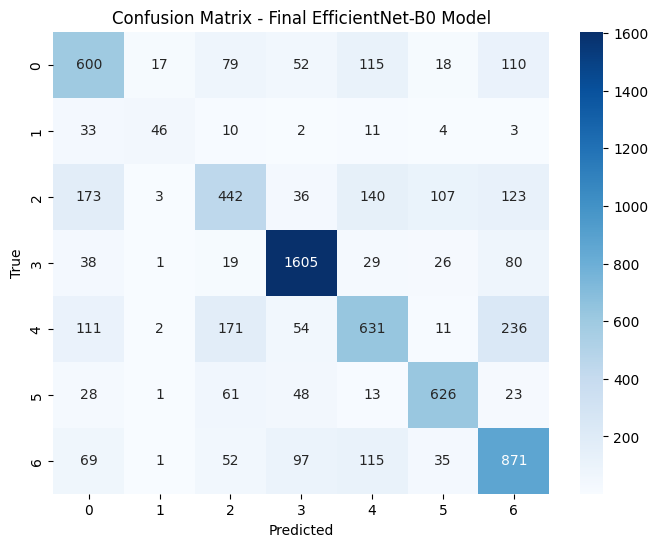

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Final EfficientNet-B0 Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()